# Lab 3 – Image Manipulations using OpenCV
Geometric and intensity transformations, per the lab handout

- Name : Abdulsamad Tuhaysha
- ID : 2240001093

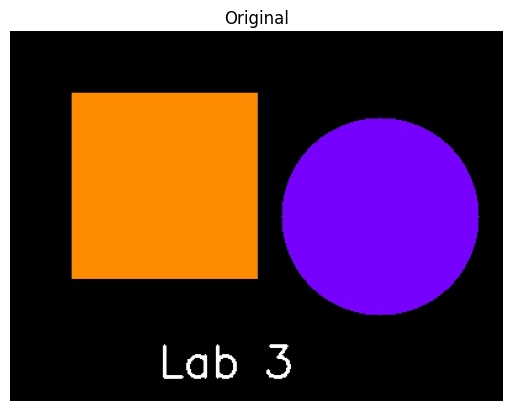

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load the input image (BGR by default in OpenCV, switch to RGB for correct display here)
img = cv2.imread('./images/input.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title('Original')
plt.axis('off')
plt.show()

## Task 1: Geometric Transformations

**1. Increase the size of the image**

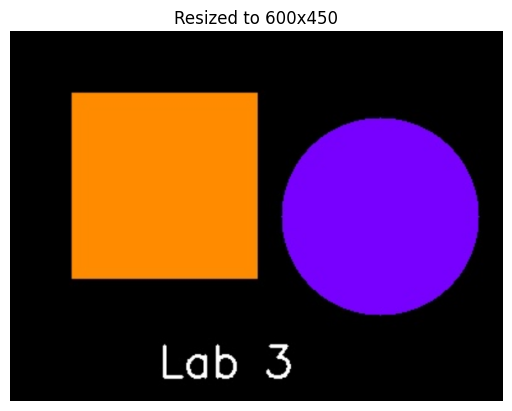

In [2]:
h, w = img.shape[:2]

# scale up by 1.5x, linear interpolation is fine for upscaling
resized = cv2.resize(img, (int(w * 1.5), int(h * 1.5)), interpolation=cv2.INTER_LINEAR)

plt.imshow(resized)
plt.title(f'Resized to {resized.shape[1]}x{resized.shape[0]}')
plt.axis('off')
plt.show()

**2. Rotate the image by 120 degrees**

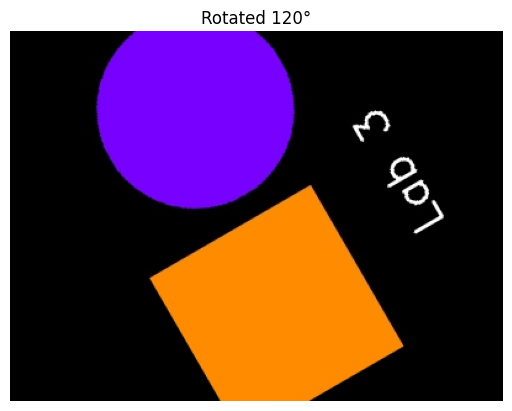

In [3]:
h, w = img.shape[:2]
center = (w // 2, h // 2)

# positive angle = counter-clockwise rotation in cv2.getRotationMatrix2D
M_rot = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated = cv2.warpAffine(img, M_rot, (w, h))

plt.imshow(rotated)
plt.title('Rotated 120°')
plt.axis('off')
plt.show()

**3. Shear the image**

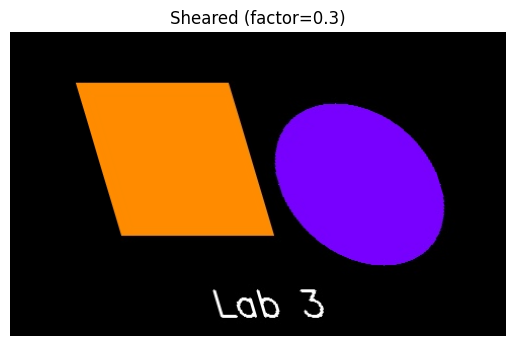

In [4]:
h, w = img.shape[:2]

# shear along x: each row shifts sideways proportional to its y position
shear_factor = 0.3
M_shear = np.float32([[1, shear_factor, 0],
                       [0, 1, 0]])
new_w = int(w + shear_factor * h)  # widen canvas so nothing gets cut off
sheared = cv2.warpAffine(img, M_shear, (new_w, h))

plt.imshow(sheared)
plt.title(f'Sheared (factor={shear_factor})')
plt.axis('off')
plt.show()

## Task 2: Intensity Transformations

**1. Negative image**

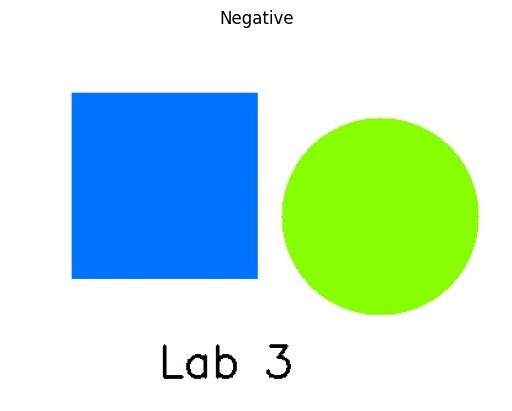

In [5]:
# negative: s = 255 - r, applied per pixel/channel
negative = 255 - img

plt.imshow(negative)
plt.title('Negative')
plt.axis('off')
plt.show()

**2. Log transformation**

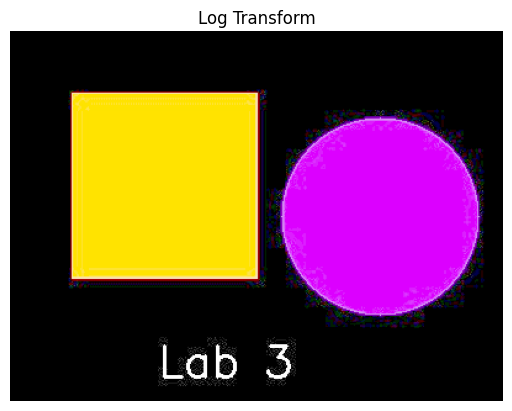

In [6]:
img_f = img.astype(np.float32)

# s = c * log(1 + r); c picked so the max input maps to 255
c = 255 / np.log(1 + np.max(img_f))
log_img = c * np.log(1 + img_f)
log_img = np.uint8(np.clip(log_img, 0, 255))

plt.imshow(log_img)
plt.title('Log Transform')
plt.axis('off')
plt.show()

**3. Power law (gamma) transformation**

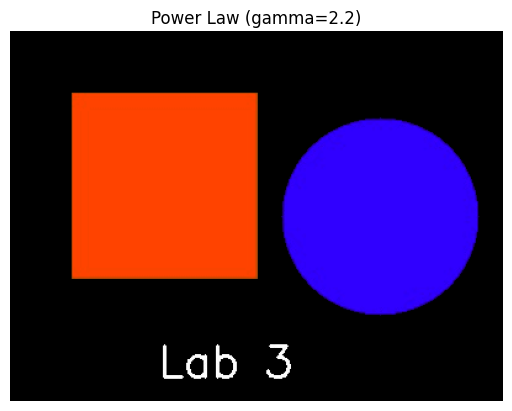

In [7]:
# gamma > 1 darkens/increases contrast in the bright regions
gamma = 2.2

img_norm = img / 255.0
gamma_img = np.power(img_norm, gamma)
gamma_img = np.uint8(gamma_img * 255)

plt.imshow(gamma_img)
plt.title(f'Power Law (gamma={gamma})')
plt.axis('off')
plt.show()